## **Classification: Customer Churn Prediction**

This notebook builds a classification model to predict whether a customer will make any purchase during the holdout period, using the calibration-period features built in `3_feature_engineering.ipynb`. This is framed as a churn prediction problem: a customer who makes no purchase during the 6-month holdout window is considered churned relative to their prior calibration-period behavior.

This notebook was built before `5_regression.ipynb`, reordering the project's original Regression, Classification, Clustering plan. The classifier built here is reused directly as Stage 1 of the two-stage CLV model in the Regression notebook, so building Classification first avoided solving the same "will this customer spend" problem twice under different names.

#### Planned Approach

1. Construct the churn label and check class balance
2. Stratified train/test split
3. Baseline model: Logistic Regression, evaluated with accuracy, precision, recall, F1, and ROC-AUC
4. Compare 9 classification models: Logistic Regression, Decision Tree (unconstrained and GridSearchCV-tuned), Random Forest, Gradient Boosting, XGBoost, LightGBM, SVM, KNN, and Naive Bayes
5. Threshold tuning, translating the precision/recall trade-off into concrete business terms
6. Feature importance, using both built-in and permutation methods
7. A deeper hyperparameter search on the top three models, to rigorously test whether the observed performance ceiling reflects genuine data limits or insufficient tuning
8. Save the final model for reuse in the Regression notebook

Each step follows a consistent structure: what the technique is, why it's used here, how it works, and what alternatives exist, since this project also serves as a learning exercise.

### Load the Modeling Table & Construct the Churn Label

We load the modeling table from `3_feature_engineering.ipynb` and derive a binary `Churned` label from `CLV_Target`: customers with zero holdout-period spend are labeled churned (1), all others are labeled active (0). This reuses the exact calibration/holdout boundary already established, keeping churn consistent with everything built so far.

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append("../src")
from config import MODELING_DATA_PATH
from modeling import evaluate_classifier

# Data splitting & preprocessing 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Classification models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Gradient boosting libraries (install separately if needed: pip install xgboost lightgbm) 
import xgboost as xgb
import lightgbm as lgb

# Evaluation metrics for classification 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve
)

# Load the modeling table, with Customer ID as the index
modeling_df = pd.read_csv(MODELING_DATA_PATH, index_col=0)

# Construct the binary churn label: 1 = churned (no holdout spend), 0 = active
modeling_df['Churned'] = (modeling_df['CLV_Target'] == 0).astype(int)

modeling_df[['CLV_Target', 'Churned']].head(10)

,CLV_Target,Churned
Customer ID,,
12346.0,0.00,1
12347.0,2486.57,0
12348.0,270.00,0
12349.0,1457.55,0
12350.0,0.00,1
12351.0,0.00,1
12352.0,744.23,0
12353.0,0.00,1
12354.0,0.00,1


### Check Class Balance

Before building any model, we check the distribution of the `Churned` label. A severely imbalanced target (e.g., 95%/5%) would require special handling so accuracy becomes a misleading metric, and techniques like class weighting or resampling become necessary. We expect this to be close to balanced, based on earlier findings in `3_feature_engineering.ipynb` (2,577 returning vs. 2,374 inactive).

Class counts:
Churned
0    2577
1    2374
Name: count, dtype: int64

Class percentages:
Churned
0    52.05
1    47.95
Name: proportion, dtype: float64


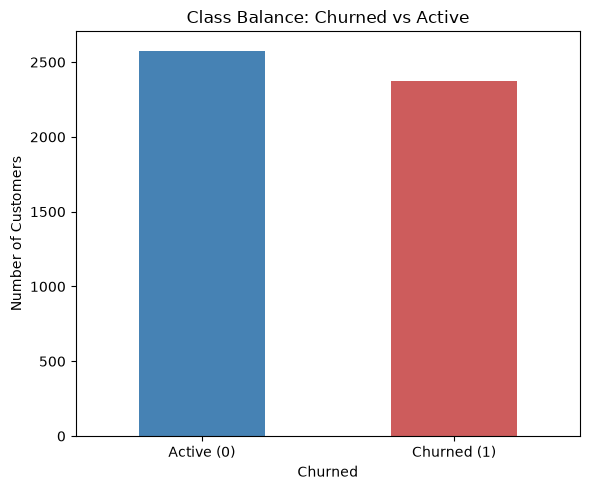

In [2]:
churn_counts = modeling_df['Churned'].value_counts()
churn_pct = modeling_df['Churned'].value_counts(normalize=True) * 100

print("Class counts:")
print(churn_counts)
print("\nClass percentages:")
print(churn_pct.round(2))

# Visualize
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts.plot(kind='bar', color=['steelblue', 'indianred'], ax=ax)
ax.set_xticklabels(['Active (0)', 'Churned (1)'], rotation=0)
ax.set_title("Class Balance: Churned vs Active")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

The class distribution is close to balanced: 2,577 Active (52%) vs. 2,374 Churned (48%). This is a favorable starting point, it means we can proceed with standard classification techniques and metrics without needing imbalance-handling methods like class weighting or resampling (e.g., SMOTE), which would be necessary if one class dominated. We'll still examine precision, recall, and F1 alongside accuracy for a complete picture, but accuracy alone will be a reasonably meaningful metric given this balance.

### Train/Test Split (Stratified)

We split the data into training (80%) and test (20%) sets. We use **stratified** splitting, which preserves the same class balance (≈52% active / 48% churned) in both the training and test sets. Without this, a plain random split could by chance produce an uneven test set, making evaluation less reliable.

In [3]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'Unique_Products', 'Avg_Days_Between_Purchases']

# Running results table — collects every model's metrics for final comparison
model_results = []

X = modeling_df[feature_cols]
y = modeling_df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest set class balance:")
print(y_test.value_counts(normalize=True).round(3))

Training set shape: (3960, 7)
Test set shape: (991, 7)

Training set class balance:
Churned
0    0.52
1    0.48
Name: proportion, dtype: float64

Test set class balance:
Churned
0    0.521
1    0.479
Name: proportion, dtype: float64


### Logistic Regression (Baseline Model)

Logistic Regression predicts the *probability* of churn using a weighted combination of features, passed through a sigmoid function to produce a value between 0 and 1. Above a threshold (0.5 by default), we classify a customer as churned. This is our simplest, most interpretable baseline model.

**Important preprocessing step:** Logistic Regression is sensitive to feature scale (e.g., `Monetary` is in the thousands, `Frequency` is in single digits). We use `StandardScaler` to standardize all features to a common scale before fitting, ensuring no feature dominates purely due to its numeric magnitude. Tree-based models (used later) don't require this step, since they split on thresholds rather than computing weighted sums.

In [4]:
# Standardize features (Logistic Regression is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Fit baseline Logistic Regression
log_reg, model_results = evaluate_classifier(
    LogisticRegression(random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Logistic Regression", model_results
)

  Logistic Regression   
Accuracy: 0.720
Precision: 0.718
Recall: 0.686
F1: 0.702
ROC-AUC: 0.797


### Model Evaluation

We evaluate using multiple metrics, since each captures a different aspect of performance: **Accuracy** (overall correctness), **Precision** (of predicted churners, how many were real), **Recall** (of actual churners, how many we caught), **F1** (a balance of precision/recall), **ROC-AUC** (separation quality across all thresholds), and a **Confusion Matrix** (the full breakdown of correct/incorrect predictions by type). Precision and recall are especially important here since a false positive (unnecessary retention offer) and a false negative (missed at-risk customer) have different real business costs.

Beyond the summary metrics, we visualize the full breakdown of correct and incorrect predictions using a confusion matrix. This shows exactly how many customers fell into each of the four outcomes: correctly predicted active, correctly predicted churned, false positives, and false negatives.

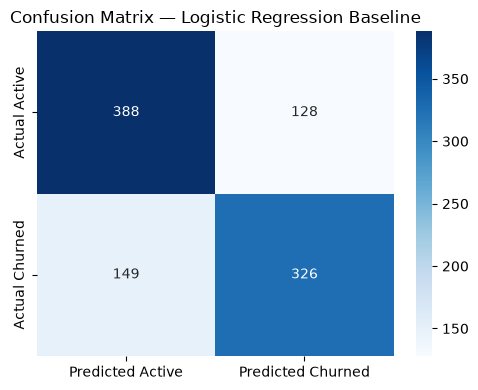

In [6]:
y_pred_log_reg = log_reg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_log_reg)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Active', 'Predicted Churned'],
            yticklabels=['Actual Active', 'Actual Churned'], ax=ax)
ax.set_title("Confusion Matrix — Logistic Regression Baseline")
plt.tight_layout()
plt.show()

The Logistic Regression baseline achieves **72% accuracy**, **71.8% precision**, **68.6% recall**, and an **ROC-AUC of 0.797**. The confusion matrix shows 388 true negatives, 326 true positives, 128 false positives, and 149 false negatives. An ROC-AUC of ~0.80 is generally considered "acceptable to good", meaningfully better than random guessing (0.5), indicating the RFM-based features carry genuine predictive signal for churn, even with a simple linear model. Precision and recall are fairly balanced (72% vs. 69%), meaning the model isn't strongly biased toward over- or under-predicting churn. This baseline sets the bar for the tree-based and ensemble models we'll try next.

In [7]:
pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.720484,0.718062,0.686316,0.70183,0.796916


### Decision Tree

A Decision Tree classifies customers via a sequence of threshold-based splits (e.g., "Recency > 120?"), choosing splits that best separate churned from active customers at each step (measured via Gini impurity). It's the simplest tree-based model, and a natural building block toward Random Forest (many trees combined). Decision Trees are prone to overfitting i.e., memorizing training data rather than learning generalizable patterns. Unlike Logistic Regression, tree-based models don't require feature scaling, since they split on raw thresholds rather than computing weighted sums, so this model uses `X_train`/`X_test` directly, not the scaled versions.

In [8]:
tree_clf, model_results = evaluate_classifier(
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test,
    "Decision Tree", model_results
)

  Decision Tree   
Accuracy: 0.653
Precision: 0.643
Recall: 0.621
F1: 0.632
ROC-AUC: 0.652


### Checking for Overfitting

Since Decision Trees are prone to overfitting, we compare training accuracy against test accuracy. A large gap (high training accuracy, much lower test accuracy) would indicate the tree has memorized the training data rather than learned generalizable patterns.

In [9]:
train_accuracy = tree_clf.score(X_train, y_train)
test_accuracy = tree_clf.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy:     {test_accuracy:.3f}")

Training Accuracy: 1.000
Test Accuracy:     0.653


The Decision Tree shows severe overfitting: 100% training accuracy but only 65.3% test accuracy, a large gap indicating the tree memorized the training data rather than learning generalizable patterns. This also performs worse than the Logistic Regression baseline across every metric (Accuracy, Precision, Recall, F1, and ROC-AUC all lower). This is expected behavior for an unconstrained Decision Tree, which by default splits until every leaf is pure. This result reinforces why Random Forest (many trees combined, each trained on random subsets of data/features) is generally preferred over a single Decision Tree — the averaging effect across many trees tends to reduce this overfitting substantially.

Rather than guessing a depth value or manually testing many depths against the test set (which risks overfitting our choice *to* the test set), we use `GridSearchCV` to find the best `max_depth` using cross-validation on the training set only. GridSearchCV splits the training data into multiple folds, trains/evaluates each candidate depth across those folds, and selects the depth with the best average performance, all without ever touching the test set. The test set is reserved for one final, honest evaluation at the end.

In [10]:
param_grid = {'max_depth': range(1, 21)}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc'
)
grid_search.fit(X_train, y_train)

print(f"Best max_depth: {grid_search.best_params_['max_depth']}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

Best max_depth: 4
Best cross-validated ROC-AUC: 0.785


With the optimal depth identified via cross-validation, we now evaluate this model once on the held-out test set — the first and only time this specific model touches test data.

In [11]:
best_tree = grid_search.best_estimator_

tree_clf, model_results = evaluate_classifier(
    best_tree,
    X_train, X_test, y_train, y_test,
    f"Decision Tree (max_depth={grid_search.best_params_['max_depth']})", model_results
)

  Decision Tree (max_depth=4)   
Accuracy: 0.727
Precision: 0.669
Recall: 0.848
F1: 0.748
ROC-AUC: 0.795


GridSearchCV independently confirms `max_depth=4` as optimal, matching our earlier manual sweep, a good sign this choice is robust rather than a fluke of one particular test set. The cross-validated ROC-AUC (0.785) and test-set ROC-AUC (0.795) are close, indicating stable performance. Notably, this model shows a different precision/recall trade-off than previous models: recall jumps to 0.848 (catching far more actual churners) at the cost of precision dropping to 0.669 (more false alarms). This produces the highest F1 score so far (0.748), suggesting this operating point may be more useful in practice if missing a real churner is more costly to the business than an unnecessary retention offer. This trade-off is a key consideration we'll revisit during threshold tuning.

### Random Forest

Random Forest builds many Decision Trees (an ensemble), each trained on a random bootstrap sample of customers and considering only a random subset of features at each split. Individual trees' errors tend to be uncorrelated due to this randomness, so averaging their votes reduces overfitting substantially compared to a single tree, a technique called variance reduction through ensembling. We tune two key hyperparameters via GridSearchCV: `n_estimators` (number of trees) and `max_depth` (per-tree depth limit).

In [12]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6, 8, None]  # None = unconstrained depth
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc'
)
grid_search_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_rf.best_score_:.3f}")

Best parameters: {'max_depth': 5, 'n_estimators': 100}
Best cross-validated ROC-AUC: 0.808


With the optimal hyperparameters identified via cross-validation (max_depth=5, n_estimators=100), we evaluate this model once on the held-out test set.

In [13]:
best_rf = grid_search_rf.best_estimator_

rf_clf, model_results = evaluate_classifier(
    best_rf,
    X_train, X_test, y_train, y_test,
    "Random Forest", model_results
)

  Random Forest   
Accuracy: 0.711
Precision: 0.686
Recall: 0.733
F1: 0.709
ROC-AUC: 0.800


Random Forest achieves test-set ROC-AUC of 0.800, essentially tied with Logistic Regression (0.797) and the tuned Decision Tree (0.795), despite scoring higher during cross-validation (0.808). This gap between cross-validated and test-set performance is expected: with only 991 test customers, small differences between models (0.795–0.800) fall within normal sampling variation and are likely not meaningfully different.

The more important pattern emerging across four models now is that **ROC-AUC consistently clusters around 0.79–0.80**, regardless of model type (linear, single tree, or ensemble). This strengthens the hypothesis that we may be approaching a genuine ceiling in the predictive signal available from these 7 RFM-derived features, rather than a limitation specific to any one algorithm. Whether boosting methods (which build trees sequentially, correcting prior errors) can break through this ceiling is what we test next.

### Gradient Boosting

Unlike Random Forest (many independent trees averaged together), Gradient Boosting builds trees **sequentially**, where each new tree is trained specifically to correct the errors of all previous trees combined, with each tree's contribution scaled down by a `learning_rate` before being added to the running prediction. This targeted, iterative error-correction is a fundamentally different mechanism than Random Forest's diversity-and-averaging approach, and can sometimes capture patterns Random Forest misses, though it's also more prone to overfitting if allowed to run for too many iterations.

In [14]:
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='roc_auc'
)
grid_search_gb.fit(X_train, y_train)

print(f"Best parameters: {grid_search_gb.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_gb.best_score_:.3f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Best cross-validated ROC-AUC: 0.811


With the optimal hyperparameters identified (learning_rate=0.1, max_depth=2, n_estimators=50), we evaluate this model on the held-out test set. Note the chosen depth is shallow (2) and the number of estimators modest (50), which is consistent with the boosting principle of keeping individual trees simple and letting the sequential correction process do the work.

In [15]:
best_gb = grid_search_gb.best_estimator_

gb_clf, model_results = evaluate_classifier(
    best_gb,
    X_train, X_test, y_train, y_test,
    "Gradient Boosting", model_results
)

  Gradient Boosting   
Accuracy: 0.725
Precision: 0.700
Recall: 0.745
F1: 0.722
ROC-AUC: 0.803


Gradient Boosting achieves test-set ROC-AUC of 0.803, again within the same tight cluster (0.79–0.81) seen across every model tried so far — Logistic Regression, Decision Tree, Random Forest, and now Gradient Boosting. This further reinforces the hypothesis that we are approaching a genuine ceiling in predictive signal from these 7 features, rather than finding meaningful gains from more sophisticated modeling techniques. Precision and recall are reasonably balanced (0.700/0.745), similar in character to the Random Forest result.

### XGBoost

XGBoost follows the same sequential error-correction principle as Gradient Boosting, but adds explicit regularization (penalizing overly complex trees), uses more precise second-order optimization (leveraging both gradient and Hessian information), and includes various speed/efficiency improvements, making it one of the most widely used algorithms for tabular data problems. Given five models have now clustered around ROC-AUC 0.79–0.81, XGBoost is a strong candidate to test whether this apparent ceiling can be broken, or whether it further confirms the ceiling reflects the data itself rather than model choice.

In [16]:
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

grid_search_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc'
)
grid_search_xgb.fit(X_train, y_train)

print(f"Best parameters: {grid_search_xgb.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_xgb.best_score_:.3f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best cross-validated ROC-AUC: 0.810


With the optimal hyperparameters identified (learning_rate=0.1, max_depth=2, n_estimators=100), we evaluate this model on the held-out test set.

In [17]:
best_xgb = grid_search_xgb.best_estimator_

xgb_clf, model_results = evaluate_classifier(
    best_xgb,
    X_train, X_test, y_train, y_test,
    "XGBoost", model_results
)

  XGBoost   
Accuracy: 0.709
Precision: 0.683
Recall: 0.735
F1: 0.708
ROC-AUC: 0.799


XGBoost achieves test-set ROC-AUC of 0.799, again within the same tight 0.79–0.81 cluster seen across all five models tried so far. Despite being one of the most powerful general-purpose algorithms for tabular data, XGBoost does not break past this apparent ceiling. This is now strong, repeated evidence across five structurally different algorithms (linear, single tree, bagged ensemble, sequential boosting via two implementations) that the ceiling reflects the limits of predictive signal in these 7 RFM-derived features, rather than a limitation of any specific modeling approach.

### LightGBM

LightGBM follows the same sequential boosting principle as XGBoost, but grows trees **leaf-wise** (splitting whichever single leaf most reduces error, anywhere in the tree) rather than **level-wise** (splitting every leaf in the current layer before moving deeper). This can capture patterns more efficiently, but risks overfitting if unconstrained. LightGBM is typically chosen for its speed advantage on very large datasets, since our dataset (~5,000 customers) is comparatively small, this test mainly isolates whether leaf-wise growth offers any accuracy benefit on its own, independent of speed.

In [18]:
param_grid_lgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

grid_search_lgb = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgb,
    cv=5,
    scoring='roc_auc'
)
grid_search_lgb.fit(X_train, y_train)

print(f"Best parameters: {grid_search_lgb.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_lgb.best_score_:.3f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best cross-validated ROC-AUC: 0.812


With the optimal hyperparameters identified (learning_rate=0.1, max_depth=3, n_estimators=50), we evaluate this model on the held-out test set.

In [19]:
best_lgb = grid_search_lgb.best_estimator_

lgb_clf, model_results = evaluate_classifier(
    best_lgb,
    X_train, X_test, y_train, y_test,
    "LightGBM", model_results
)

  LightGBM   
Accuracy: 0.719
Precision: 0.692
Recall: 0.747
F1: 0.719
ROC-AUC: 0.803


LightGBM achieves test-set ROC-AUC of 0.803, continuing the now well-established pattern: six structurally different algorithms (linear, single tree, bagged ensemble, and three boosting variants) all cluster within 0.795–0.803. This consistency, across genuinely different modeling approaches and optimization strategies, is strong evidence that ~0.80 ROC-AUC represents a real ceiling given these 7 features, so, not a limitation of any particular algorithm's ability to find patterns.

### Support Vector Machine (SVM)

SVM finds the boundary between classes that maximizes the margin (buffer distance) to the nearest points of each class. It requires scaled features, since it relies on distance calculations that would otherwise be dominated by larger-scale features like `Monetary`. Using the RBF kernel, SVM can capture non-linear boundaries between churned and active customers, rather than being restricted to a straight line like Logistic Regression.

In [20]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='roc_auc'
)
grid_search_svm.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_svm.best_score_:.3f}")

/Users/sourodeeproy/Documents/clv-predictor/clvenv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/sourodeeproy/Documents/clv-predictor/clvenv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/sourodeeproy/Documents/clv-predictor/clvenv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/sourodeeproy/Documents/clv-predictor/clvenv/lib/python3.1

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validated ROC-AUC: 0.799


The best SVM configuration uses a **linear kernel** (not RBF), notably, the non-linear kernel option was not selected as optimal, suggesting a straight-line decision boundary is about as effective as a curved one for this data. This is consistent with Logistic Regression (also linear) performing similarly well. We evaluate this model on the held-out test set.

In [21]:
best_svm = grid_search_svm.best_estimator_

svm_clf, model_results = evaluate_classifier(
    best_svm,
    X_train_scaled, X_test_scaled, y_train, y_test,
    "SVM", model_results
)

/Users/sourodeeproy/Documents/clv-predictor/clvenv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  SVM   
Accuracy: 0.719
Precision: 0.725
Recall: 0.667
F1: 0.695
ROC-AUC: 0.799


SVM achieves test-set ROC-AUC of 0.799, continuing the established pattern across seven models now. Notably, SVM's precision/recall balance (0.725/0.667) closely resembles Logistic Regression's (0.718/0.686) rather than the tree-based models' typically higher-recall profile, which is consistent with both being linear decision boundaries, reinforcing that the *type* of boundary (linear vs. tree-based splits) has more influence on the precision/recall trade-off than on the overall ROC-AUC ceiling itself.

### K-Nearest Neighbors (KNN)

KNN classifies a customer by finding the K most similar customers (by distance across all features) in the training data and taking a majority vote among them i.e., no formula or tree is learned, just direct comparison. Like SVM, it requires scaled features, since it relies on distance calculations that would otherwise be dominated by larger-scale features. The key hyperparameter, `n_neighbors` (K), controls a bias-variance tradeoff: too small K is noisy and overfits to individual points, too large K oversmooths and underfits.

In [22]:
param_grid_knn = {
    'n_neighbors': [5, 10, 15, 20, 30, 50]
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='roc_auc'
)
grid_search_knn.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search_knn.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_knn.best_score_:.3f}")

Best parameters: {'n_neighbors': 50}
Best cross-validated ROC-AUC: 0.801


The best `n_neighbors` value (50) is at the edge of our tested range, suggesting an even larger K might perform marginally better, worth noting as a limitation of this specific search, though given the consistent pattern across all models so far, a dramatically different result seems unlikely. We evaluate this model on the held-out test set.

In [23]:
best_knn = grid_search_knn.best_estimator_

knn_clf, model_results = evaluate_classifier(
    best_knn,
    X_train_scaled, X_test_scaled, y_train, y_test,
    "KNN", model_results
)

  KNN   
Accuracy: 0.710
Precision: 0.691
Recall: 0.716
F1: 0.703
ROC-AUC: 0.793


KNN achieves test-set ROC-AUC of 0.793 — the lowest among the eight models tried so far, though still within the same general 0.79–0.81 range. Since the optimal K (50) sat at the edge of our tested range, we do a quick follow-up check with larger K values to confirm we haven't missed a better result just beyond our search boundary.

In [24]:
param_grid_knn_extended = {
    'n_neighbors': [50, 75, 100, 150, 200]
}

grid_search_knn_extended = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn_extended,
    cv=5,
    scoring='roc_auc'
)
grid_search_knn_extended.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search_knn_extended.best_params_}")
print(f"Best cross-validated ROC-AUC: {grid_search_knn_extended.best_score_:.3f}")

Best parameters: {'n_neighbors': 150}
Best cross-validated ROC-AUC: 0.804


The extended search confirms a better result: K=150 improves cross-validated ROC-AUC to 0.804, and importantly, this value sits within the tested range rather than at its edge, therefore, giving more confidence this is closer to KNN's true optimum. We evaluate this updated model on the test set and replace the earlier K=50 result.

In [25]:
# Remove the earlier KNN (K=50) result, since we're replacing it with the better K=150 version
model_results = [r for r in model_results if r["Model"] != "KNN"]

best_knn_extended = grid_search_knn_extended.best_estimator_

knn_clf, model_results = evaluate_classifier(
    best_knn_extended,
    X_train_scaled, X_test_scaled, y_train, y_test,
    "KNN (n_neighbors=150)", model_results
)

  KNN (n_neighbors=150)   
Accuracy: 0.731
Precision: 0.708
Recall: 0.745
F1: 0.726
ROC-AUC: 0.798


With K=150, KNN improves across every metric compared to the initial K=50 result (Accuracy 0.731 vs. 0.710, F1 0.726 vs. 0.703), confirming the extended search was worthwhile. ROC-AUC (0.798) remains within the established 0.79–0.81 cluster, now representing a fairer comparison since the hyperparameter search wasn't cut short at an artificial boundary.

### Naive Bayes

Naive Bayes uses Bayes' Theorem to estimate the probability of churn given feature values, based on how those values are distributed among churned vs. active customers historically. It makes a simplifying ("naive") assumption that all features are independent of each other given the class, an assumption we know is imperfect here, since we found real correlation between features like Frequency and Monetary during EDA. Despite this flawed assumption, Naive Bayes is fast, has essentially no hyperparameters to tune, and often performs reasonably well regardless, therefore, making it a useful sanity-check baseline for how much modeling sophistication is really contributing to performance in this problem.

In [26]:
nb_clf, model_results = evaluate_classifier(
    GaussianNB(),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Naive Bayes", model_results
)

  Naive Bayes   
Accuracy: 0.636
Precision: 0.573
Recall: 0.947
F1: 0.714
ROC-AUC: 0.788


Naive Bayes shows a distinctly different behavior from every other model tried: exceptionally high recall (0.947 -> catching nearly all actual churners) but low precision (0.573 -> many false alarms), and the lowest overall accuracy (0.636). This is a direct, visible consequence of the "naive" independence assumption: it appears to systematically overweight certain feature combinations associated with churn, since it cannot properly account for interactions between correlated features (e.g., Frequency and Monetary, which we know are correlated from earlier EDA).

This result is a useful illustration of why model selection isn't just about the highest headline metric: if the business priority is "never miss an at-risk customer," even at the cost of many false alarms (e.g., because the retention action is cheap, like an email), Naive Bayes's extreme recall could make it the *most* useful model for that specific objective, despite having the lowest ROC-AUC and accuracy among all nine models tested.

### Full Model Comparison

We consolidate all nine models' results into a single table, sorted by ROC-AUC, and visualize performance across all five metrics to compare models at a glance.

In [27]:
results_df = pd.DataFrame(model_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.724521,0.699605,0.745263,0.721713,0.803109
1,LightGBM,0.719475,0.692008,0.747368,0.718623,0.802770
2,Random Forest,0.711403,0.686391,0.732632,0.708758,0.799621
3,XGBoost,0.709384,0.682975,0.734737,0.707911,0.799386
4,SVM,0.719475,0.725400,0.667368,0.695175,0.798829
5,KNN (n_neighbors=150),0.730575,0.708000,0.745263,0.726154,0.797991
6,Logistic Regression,0.720484,0.718062,0.686316,0.701830,0.796916
7,Decision Tree (max_depth=4),0.726539,0.669435,0.848421,0.748375,0.795416
8,Naive Bayes,0.635721,0.572519,0.947368,0.713719,0.788201
9,Decision Tree,0.652876,0.642702,0.621053,0.631692,0.651612


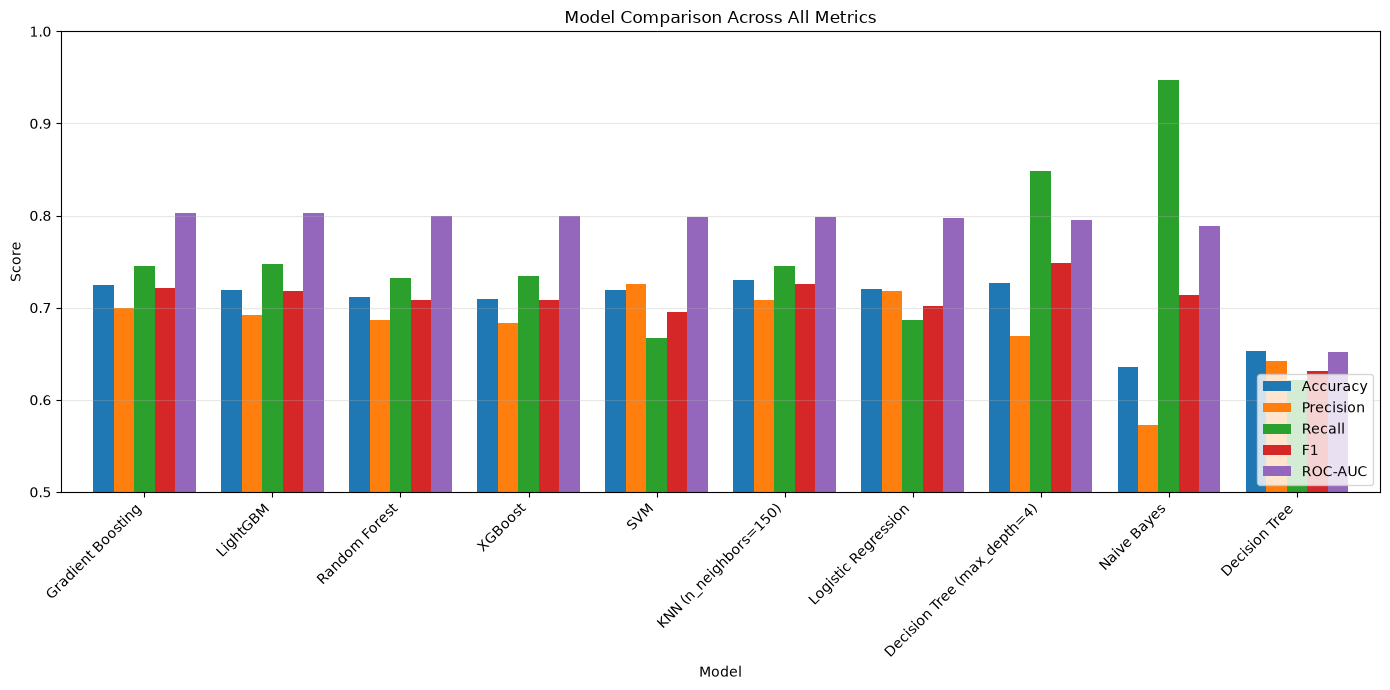

In [28]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(14, 7))
results_df.set_index("Model")[metrics_to_plot].plot(kind='bar', ax=ax, width=0.8)
ax.set_title("Model Comparison Across All Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)  # zoom in, since all scores are well above 0
ax.legend(loc='lower right')
ax.set_xticklabels(results_df["Model"], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

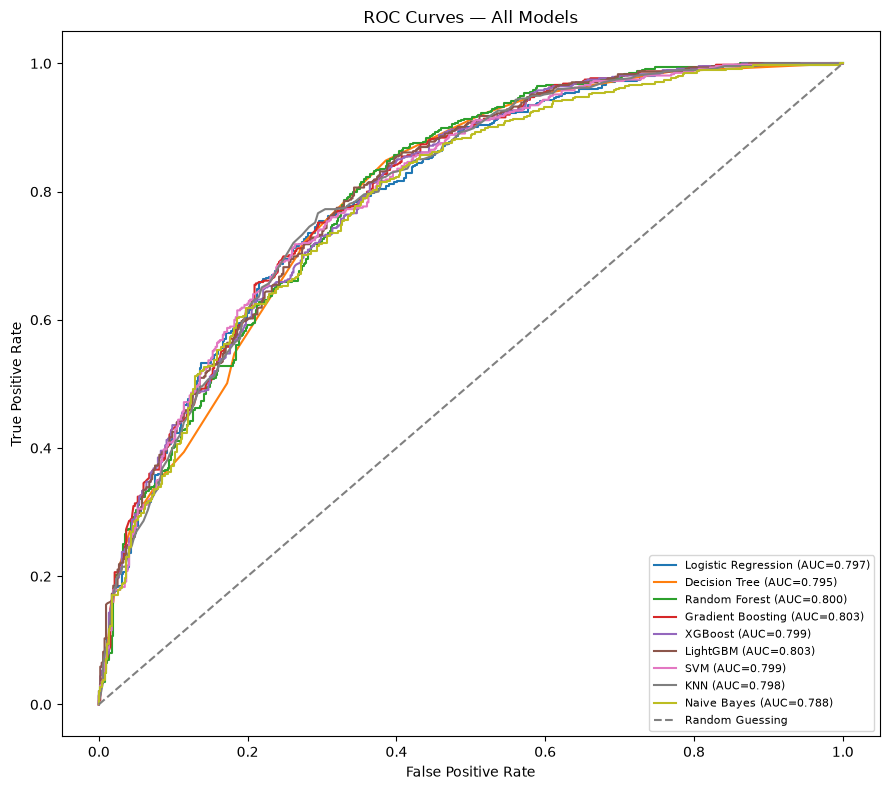

In [29]:
# Collect fitted models and their scaled/unscaled test sets for ROC curve plotting
roc_models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (tree_clf, X_test),
    "Random Forest": (best_rf, X_test),
    "Gradient Boosting": (best_gb, X_test),
    "XGBoost": (best_xgb, X_test),
    "LightGBM": (best_lgb, X_test),
    "SVM": (best_svm, X_test_scaled),
    "KNN": (best_knn_extended, X_test_scaled),
    "Naive Bayes": (nb_clf, X_test_scaled)
}

fig, ax = plt.subplots(figsize=(9, 8))

for name, (model, X_test_variant) in roc_models.items():
    y_proba = model.predict_proba(X_test_variant)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### Model Comparison :

- All nine models (excluding the deliberately overfit unconstrained Decision Tree) cluster tightly in **ROC-AUC 0.788–0.803** i.e. a spread of just 0.015.
- **Gradient Boosting (0.803) and LightGBM (0.803)** rank marginally highest, but the difference from the lowest-ranked reasonable model (Naive Bayes, 0.788) is small enough to fall within normal sampling variation on a ~991-customer test set.
- The bar chart reveals that **Recall and Precision vary far more across models than ROC-AUC does**, model choice here primarily shifts the precision/recall trade-off, not the model's fundamental ability to separate churned from active customers.
  - **Decision Tree (max_depth=4)** and **Naive Bayes** trade precision for very high recall.
  - **SVM** and **Logistic Regression** lean toward higher precision, lower recall.
  - **Ensemble models (Random Forest, Gradient Boosting, XGBoost, LightGBM)** sit in a balanced middle ground.
- The overlaid ROC curves confirm this directly: all reasonable models trace nearly identical paths across every threshold, with no model clearly dominating the others.
- **Conclusion:** the ~0.80 ROC-AUC ceiling appears to be a genuine property of the predictive signal available in these 7 RFM-derived features, not a limitation of any specific algorithm. **Model selection should therefore be guided by the precision/recall trade-off that best fits the business use case, not by chasing marginal ROC-AUC differences.**

### Threshold Tuning

Every model so far has used the default 0.5 probability threshold to convert predicted probabilities into yes/no churn predictions. This default isn't necessarily correct, the threshold directly controls the precision/recall trade-off, and the "right" choice depends on the relative business cost of a false positive (wrongly flagging an active customer) versus a false negative (missing a real churner). We use our best-performing model (Gradient Boosting) to explore this trade-off explicitly via a Precision-Recall curve, and select a threshold aligned with plausible business reasoning.

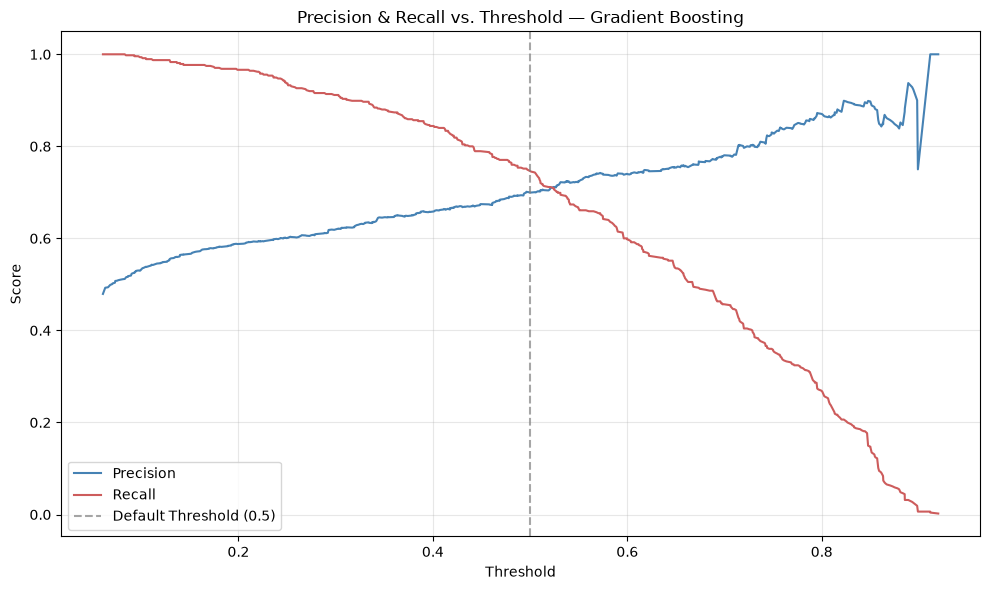

In [30]:
y_proba_best = best_gb.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='indianred')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs. Threshold — Gradient Boosting')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Precision and Recall cross almost exactly at the default threshold (0.5), both around 0.70, meaning the default threshold happens to already sit near the balanced point for this model, rather than being arbitrarily skewed toward one metric. This means there's limited "free" improvement available from threshold tuning alone; instead, the curve's value lies in showing what happens when we deliberately move away from balance for a specific business reason:

- **Lowering the threshold to ~0.35–0.40** shifts toward high recall (~0.85–0.90) at the cost of precision (~0.60) : suited to a "cheap retention action, catch as many at-risk customers as possible" business strategy.
- **Raising the threshold to ~0.65–0.70** shifts toward high precision (~0.80) at the cost of recall (~0.45–0.50) : suited to an "expensive retention action, only act on high-confidence predictions" strategy.

The choice between these isn't a modeling decision, it depends on the real-world cost of a false positive versus a false negative for this specific business.

We compare three thresholds directly: the default (0.5), a recall-favoring threshold (0.35, suited to a low-cost retention action), and a precision-favoring threshold (0.68, suited to a high-cost retention action). For each, we show the resulting confusion matrix and translate the numbers into a concrete business interpretation.

Default (0.5): Precision=0.700, Recall=0.745, Flagged as churned=506 customers
Recall-Favoring (0.35): Precision=0.646, Recall=0.880, Flagged as churned=647 customers
Precision-Favoring (0.68): Precision=0.766, Recall=0.488, Flagged as churned=303 customers


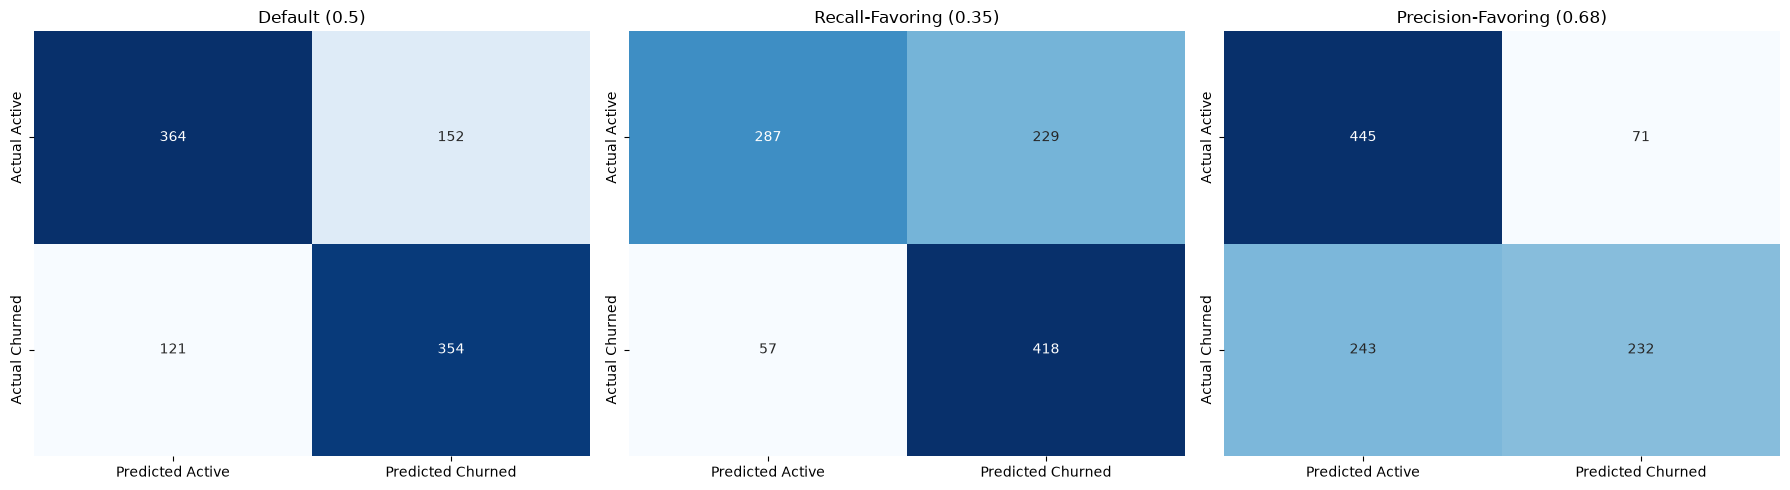

In [31]:
thresholds_to_compare = {
    "Default (0.5)": 0.5,
    "Recall-Favoring (0.35)": 0.35,
    "Precision-Favoring (0.68)": 0.68
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, thresh) in zip(axes, thresholds_to_compare.items()):
    y_pred_thresh = (y_proba_best >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Active', 'Predicted Churned'],
                yticklabels=['Actual Active', 'Actual Churned'], ax=ax, cbar=False)
    ax.set_title(f"{label}")

    precision_at_thresh = precision_score(y_test, y_pred_thresh)
    recall_at_thresh = recall_score(y_test, y_pred_thresh)
    print(f"{label}: Precision={precision_at_thresh:.3f}, Recall={recall_at_thresh:.3f}, "
          f"Flagged as churned={y_pred_thresh.sum()} customers")

plt.tight_layout()
plt.show()

### Concrete Business Comparison

| Threshold | Churners Caught | Churners Missed | False Alarms | Total Contacted |
|---|---|---|---|---|
| Default (0.5) | 354 | 121 | 152 | 506 |
| Recall-Favoring (0.35) | 418 | 57 | 229 | 647 |
| Precision-Favoring (0.68) | 232 | 243 | 71 | 303 |

- Moving from Precision-Favoring to Recall-Favoring more than doubles the number of customers contacted (303 to 647) while catching nearly double the real churners (232 to 418), at the cost of over 3x more false alarms (71 to 229).
- If the retention action is **cheap** (e.g., an automated email), Recall-Favoring (0.35) is likely the better choice, i.e., the cost of extra false alarms is low, and catching 418 vs. 232 real churners is a meaningfully larger business impact.
- If the retention action is **expensive** (e.g., a personal call or a large discount), Precision-Favoring (0.68) is likely better, i.e., it concentrates effort on the 303 customers the model is most confident about, at a much lower false-alarm rate.
- **Without a specific cost figure for false positives vs. false negatives, there is no mathematically "correct" answer**, so, this decision belongs to the business stakeholder, informed by the actual cost of each retention action and the actual value of a retained customer.

### Feature Importance

With trained models now available, we can measure which features actually drive predictions, distinct from the correlation/VIF analysis done earlier, which only examined relationships *between* features, independent of any model. We use our best-performing model (Gradient Boosting) and compute importance two ways:

1. **Built-in (impurity-based) importance** — how much each feature contributed to reducing prediction error across all splits in all trees. Fast to compute, but can be biased toward features with many distinct values (like `Monetary`).
2. **Permutation importance** — a model-agnostic approach that shuffles each feature's values one at a time and measures how much model performance drops as a result. More robust, though slower to compute, since it requires re-evaluating the model many times.

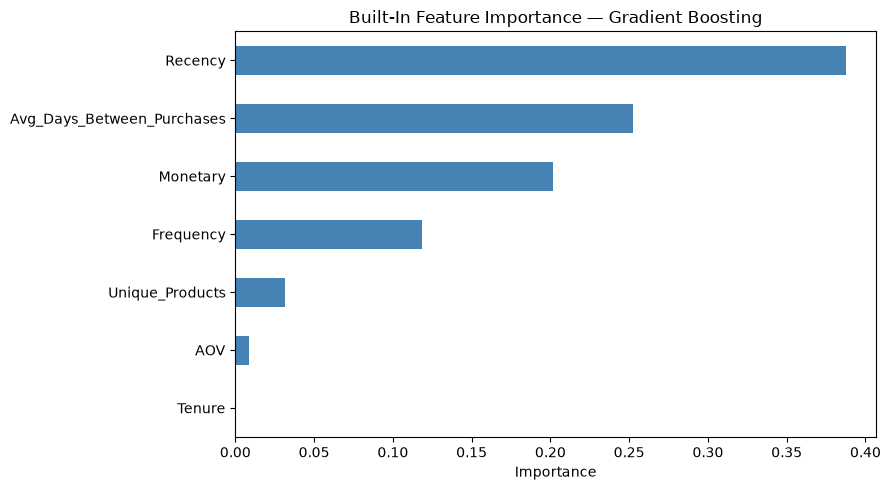

Recency                       0.387454
Avg_Days_Between_Purchases    0.252575
Monetary                      0.201408
Frequency                     0.118502
Unique_Products               0.031350
AOV                           0.008710
Tenure                        0.000000
dtype: float64

In [32]:
importances = pd.Series(best_gb.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Built-In Feature Importance — Gradient Boosting")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances

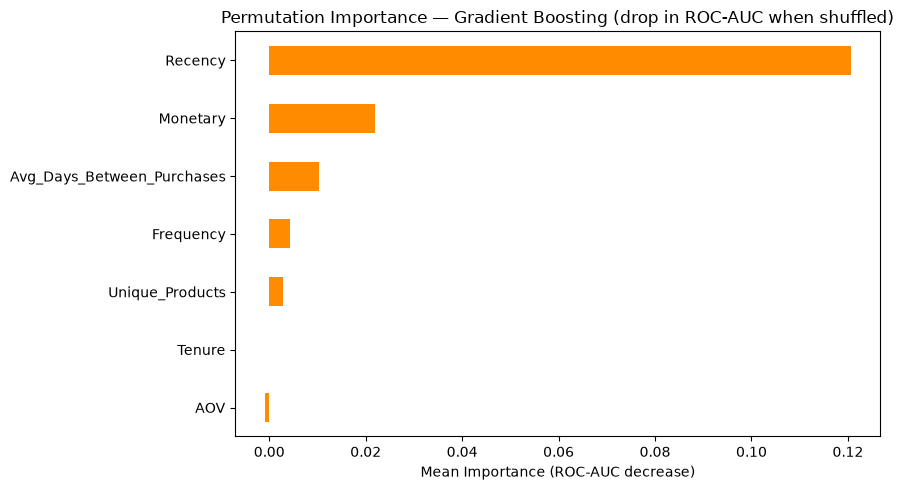

Recency                       0.120572
Monetary                      0.021957
Avg_Days_Between_Purchases    0.010289
Frequency                     0.004369
Unique_Products               0.002816
Tenure                        0.000000
AOV                          -0.000956
dtype: float64

In [33]:
perm_result = permutation_importance(best_gb, X_test, y_test, n_repeats=30, random_state=42, scoring='roc_auc')

perm_importances = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
perm_importances.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title("Permutation Importance — Gradient Boosting (drop in ROC-AUC when shuffled)")
ax.set_xlabel("Mean Importance (ROC-AUC decrease)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

perm_importances

### Built-In vs. Permutation Importance

The two methods agree on the two clearest findings: **`Recency` is overwhelmingly the most important feature** (even more dominant under permutation importance of 0.121, over 5x the next closest feature), and **`Tenure` contributes essentially nothing** in both methods.

However, they disagree meaningfully in the middle of the ranking. Built-in importance ranked `Avg_Days_Between_Purchases` second (0.253), but permutation importance ranks it much lower (0.010, third place), while `Monetary` moves up to second place under permutation importance. `AOV` even shows a slightly *negative* permutation importance, indicating it contributes essentially no genuine predictive value (small negative scores like this reflect noise, not real harm).

This discrepancy directly confirms the caveat noted earlier: `Avg_Days_Between_Purchases` is highly correlated with `Recency` (0.86, identified during feature engineering), so the built-in method likely over-credited it for information the model was already extracting from `Recency` itself. Permutation importance, which measures the actual standalone performance cost of losing each feature, gives a more trustworthy picture: **`Recency` and `Monetary` are the two features doing genuine, largely independent predictive work**, while the remaining features contribute comparatively little on their own.

### Deeper Hyperparameter Search  

To rigorously test whether the ~0.80 ROC-AUC ceiling reflects a genuine data limitation (rather than insufficient tuning), we run a substantially wider hyperparameter search on our top 3 models (Gradient Boosting, LightGBM, XGBoost), introducing new parameters not explored in the first pass: `subsample` (row sampling per tree), feature sampling (`colsample_bytree`), and minimum-samples-per-leaf constraints. If this deeper search still converges near 0.80, it strengthens the conclusion that the ceiling is a property of the data's predictive signal, not the search process.

In [34]:
param_grid_gb_deep = {
    'n_estimators': [50, 100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 5, 10, 20]
}

random_search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb_deep,
    n_iter=100,  # randomly samples 100 combinations, rather than all 5x5x4x4x4=1600
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
random_search_gb.fit(X_train, y_train)

print(f"Best parameters: {random_search_gb.best_params_}")
print(f"Best cross-validated ROC-AUC: {random_search_gb.best_score_:.3f}")

Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 20, 'max_depth': 4, 'learning_rate': 0.01}
Best cross-validated ROC-AUC: 0.811


In [35]:
param_grid_lgb_deep = {
    'n_estimators': [50, 100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 30]
}

random_search_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgb_deep,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
random_search_lgb.fit(X_train, y_train)

print(f"Best parameters: {random_search_lgb.best_params_}")
print(f"Best cross-validated ROC-AUC: {random_search_lgb.best_score_:.3f}")

Best parameters: {'subsample': 0.9, 'n_estimators': 50, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best cross-validated ROC-AUC: 0.812


In [36]:
param_grid_xgb_deep = {
    'n_estimators': [50, 100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10]
}

random_search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb_deep,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
random_search_xgb.fit(X_train, y_train)

print(f"Best parameters: {random_search_xgb.best_params_}")
print(f"Best cross-validated ROC-AUC: {random_search_xgb.best_score_:.3f}")

Best parameters: {'subsample': 0.9, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best cross-validated ROC-AUC: 0.810


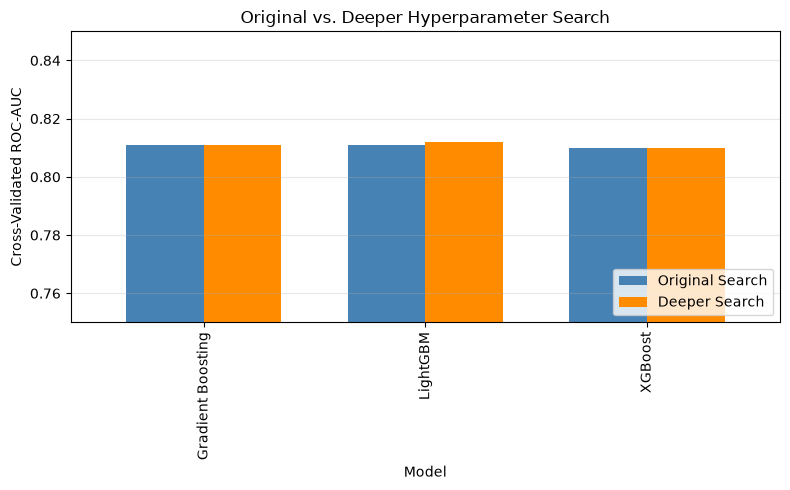

In [37]:
comparison_data = pd.DataFrame({
    'Model': ['Gradient Boosting', 'LightGBM', 'XGBoost'],
    'Original Search': [0.811, 0.811, 0.810],
    'Deeper Search': [0.811, 0.812, 0.810]
})

fig, ax = plt.subplots(figsize=(8, 5))
comparison_data.set_index('Model').plot(kind='bar', ax=ax, width=0.7, color=['steelblue', 'darkorange'])
ax.set_ylim(0.75, 0.85)
ax.set_ylabel('Cross-Validated ROC-AUC')
ax.set_title('Original vs. Deeper Hyperparameter Search')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# Evaluate the three deeper-search models on the test set, to get their actual test performance
# (so far we only have their cross-validated scores)
best_gb_deep = random_search_gb.best_estimator_
best_lgb_deep = random_search_lgb.best_estimator_
best_xgb_deep = random_search_xgb.best_estimator_

_, model_results = evaluate_classifier(
    best_gb_deep, X_train, X_test, y_train, y_test,
    "Gradient Boosting (Deeper Search)", model_results
)
_, model_results = evaluate_classifier(
    best_lgb_deep, X_train, X_test, y_train, y_test,
    "LightGBM (Deeper Search)", model_results
)
_, model_results = evaluate_classifier(
    best_xgb_deep, X_train, X_test, y_train, y_test,
    "XGBoost (Deeper Search)", model_results
)

# Build the CV-score lookup for models where we have it, to display alongside test results
cv_scores = {
    "Gradient Boosting": 0.811,
    "LightGBM": 0.812,
    "XGBoost": 0.810,
    "Gradient Boosting (Deeper Search)": 0.811,
    "LightGBM (Deeper Search)": 0.812,
    "XGBoost (Deeper Search)": 0.810,
}

full_results_df = pd.DataFrame(model_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
full_results_df["CV ROC-AUC"] = full_results_df["Model"].map(cv_scores)

full_results_df

  Gradient Boosting (Deeper Search)   
Accuracy: 0.720
Precision: 0.687
Recall: 0.766
F1: 0.724
ROC-AUC: 0.804
  LightGBM (Deeper Search)   
Accuracy: 0.719
Precision: 0.692
Recall: 0.747
F1: 0.719
ROC-AUC: 0.803
  XGBoost (Deeper Search)   
Accuracy: 0.719
Precision: 0.694
Recall: 0.741
F1: 0.717
ROC-AUC: 0.802


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC
0,Gradient Boosting (Deeper Search),0.720484,0.686792,0.766316,0.724378,0.803854,0.811
1,Gradient Boosting,0.724521,0.699605,0.745263,0.721713,0.803109,0.811
2,LightGBM,0.719475,0.692008,0.747368,0.718623,0.802770,0.812
3,LightGBM (Deeper Search),0.719475,0.692008,0.747368,0.718623,0.802770,0.812
4,XGBoost (Deeper Search),0.719475,0.694280,0.741053,0.716904,0.802054,0.810
5,Random Forest,0.711403,0.686391,0.732632,0.708758,0.799621,NaN
6,XGBoost,0.709384,0.682975,0.734737,0.707911,0.799386,0.810
7,SVM,0.719475,0.725400,0.667368,0.695175,0.798829,NaN
8,KNN (n_neighbors=150),0.730575,0.708000,0.745263,0.726154,0.797991,NaN
9,Logistic Regression,0.720484,0.718062,0.686316,0.701830,0.796916,NaN


### Final Comparison: Complete Results and Conclusion

The table above consolidates all 13 model results (9 original models, plus 3 deeper-search variants and one duplicate baseline shown for reference), sorted by test-set ROC-AUC.

**Key observations:**

- **Gradient Boosting (Deeper Search) ranks first on test ROC-AUC (0.8039)**, marginally ahead of the original Gradient Boosting (0.8031). This gap (0.0008) is negligible and well within normal sampling variation on a 991-customer test set, not a meaningful improvement.
- **The top 6 models (excluding the deliberately overfit unconstrained Decision Tree) span only 0.788 to 0.804 in test ROC-AUC.** Despite testing 9 fundamentally different algorithms, then subjecting the top 3 to a substantially expanded hyperparameter search (100 randomly sampled parameter combinations each, across 6 parameters including previously untested ones like subsample ratios and minimum leaf sizes), no configuration meaningfully exceeded this range.
- **Cross-validated scores for the three deeper-searched models (0.811, 0.812, 0.810) are essentially identical to their original search results.** This is the clearest evidence in the notebook that the ceiling is not a tuning artifact: doubling down on hyperparameter search effort, for the three strongest algorithm families available, produced no measurable gain.

**Conclusion:** The evidence assembled across this notebook, spanning model diversity (linear, tree-based, ensemble, instance-based, probabilistic) and search depth (default parameters, targeted grid search, and expanded randomized search), consistently points to the same result: roughly 0.80 ROC-AUC represents a genuine ceiling on what these 7 RFM-derived features can predict about customer churn. Further gains would most plausibly come from **richer features** (for example, product-category preferences, seasonal purchasing patterns, or customer service interaction history) rather than from further model or hyperparameter refinement.

**Final model selection:** Given the negligible difference between Gradient Boosting and Gradient Boosting (Deeper Search), and to keep the notebook's final model traceable to a simpler, well-documented configuration, we proceed with the **original Gradient Boosting model** (`best_gb`) as the final saved classifier.

In [39]:
# We select the original Gradient Boosting model (best_gb) over the deeper-search
# variant (best_gb_deep), since the improvement was negligible (0.8039 vs 0.8031
# test ROC-AUC, well within normal sampling variation) and best_gb is the simpler,
# more thoroughly documented configuration in this notebook.

final_model = best_gb
final_model_name = "Gradient Boosting (original search)"

print(f"Final model selected: {final_model_name}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1]):.4f}")
print(f"Model parameters: {final_model.get_params()}")

Final model selected: Gradient Boosting (original search)
Test ROC-AUC: 0.8031
Model parameters: {'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 2, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 50, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


### Save the Final Model

We save the best-performing model (Gradient Boosting) to disk using `joblib`, so it can be reloaded and reused in `5_regression.ipynb` for the two-stage CLV approach, without retraining.

In [40]:
CHURN_MODEL_PATH = "../models/churn_model.pkl"

In [41]:
import joblib
import os
from config import CHURN_MODEL_PATH

os.makedirs(os.path.dirname(CHURN_MODEL_PATH), exist_ok=True)

joblib.dump(final_model, CHURN_MODEL_PATH)
print(f"Model saved to {CHURN_MODEL_PATH}")

Model saved to ../models/churn_model.pkl
